# TinyLlama QLoRA Fine-Tuning on Women's Rights in India (Legal Dataset)
## Pipeline: TinyLlama-1.1B → QLoRA SFT → LegalBench Benchmark

**Flow:**
```
TinyLlama-1.1B-Chat-v1.0 (4-bit quantized)
         ↓
QLoRA SFT on /content/legal_dataset.jsonl
         ↓
Benchmark on LegalBench (abercrombie split)
```

> ⚠️ **Runtime:** Make sure you're on **GPU** (`Runtime → Change runtime type → T4 GPU`)

---
## 📦 Cell 1 — Install Dependencies

In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Dependency Install (Colab Python 3.12 + CUDA 12 Fixed)
# ════════════════════════════════════════════════════════════════

import subprocess, sys

# ── Step 1: Fix numpy FIRST (blocks 12+ packages otherwise) ──────────────────
print("📦 Step 1/4: Upgrading numpy...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "numpy>=2.0.0"], check=True)

# ── Step 2: Install bitsandbytes CUDA 12 wheel explicitly ─────────────────────
# Standard pip sometimes pulls CPU-only wheel — force the CUDA build
print("📦 Step 2/4: Installing bitsandbytes (CUDA 12)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "bitsandbytes>=0.45.3"], check=True)

# ── Step 3: Install fully compatible ML stack ─────────────────────────────────
# peft>=0.13.0  → adds is_eetq_available (fixes import crash)
# transformers==4.44.2 → stable, works with peft 0.13 + trl 0.11
# trl==0.11.4   → SFTTrainer API compatible with above
print("📦 Step 3/4: Installing ML stack...")
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.44.2",
    "peft==0.13.2",
    "trl==0.11.4",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "scipy",
    "einops",
    "sentencepiece",
    "scikit-learn",
    "rouge-score",
    "evaluate",
], check=True)

# ── Step 4: Verify CUDA binary is present ─────────────────────────────────────
print("\n📦 Step 4/4: Verifying bitsandbytes CUDA binary...")
import glob, os

cuda_bins = glob.glob(
    "/usr/local/lib/python3.12/dist-packages/bitsandbytes/libbitsandbytes_cuda*.so"
)
cpu_bins = glob.glob(
    "/usr/local/lib/python3.12/dist-packages/bitsandbytes/libbitsandbytes_cpu*.so"
)

if cuda_bins:
    print(f"  ✅ CUDA binary found  : {os.path.basename(cuda_bins[0])}")
else:
    print(f"  ⚠️  No CUDA binary found. Runtime restart required.")
    print(f"  CPU bins present     : {[os.path.basename(b) for b in cpu_bins]}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("✅ Installation complete.")
print("="*55)
print("⚠️  MANDATORY NEXT STEP:")
print("   Runtime → Restart session  (Ctrl+M .)")
print("   Then run Cell 2 onwards — DO NOT re-run Cell 1.")
print("="*55)

📦 Step 1/4: Upgrading numpy...
📦 Step 2/4: Installing bitsandbytes (CUDA 12)...
📦 Step 3/4: Installing ML stack...

📦 Step 4/4: Verifying bitsandbytes CUDA binary...
  ✅ CUDA binary found  : libbitsandbytes_cuda120.so

✅ Installation complete.
⚠️  MANDATORY NEXT STEP:
   Runtime → Restart session  (Ctrl+M .)
   Then run Cell 2 onwards — DO NOT re-run Cell 1.


In [1]:
# ── Cell 2: Import guard — run this AFTER restarting runtime ──────────────────
import torch

# Confirm GPU is visible
assert torch.cuda.is_available(), (
    "❌ GPU not detected!\n"
    "   Go to: Runtime → Change runtime type → Hardware accelerator → T4 GPU"
)

# Confirm bitsandbytes has CUDA (not CPU-only build)
import bitsandbytes as bnb
from bitsandbytes.cuda_specs import get_cuda_version_tuple
cuda_ver = get_cuda_version_tuple()
assert cuda_ver is not None, (
    "❌ bitsandbytes CPU-only build.\n"
    "   Fix: Runtime → Restart session, then start from Cell 2."
)

import warnings
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, set_seed,
)
from peft import (
    LoraConfig, TaskType, get_peft_model,
    prepare_model_for_kbit_training, PeftModel,
)
from trl import SFTTrainer, SFTConfig          # trl 0.11 uses SFTConfig
from datasets import Dataset as HFDataset
import json, os, math, warnings, requests, numpy as np, pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
set_seed(42)

MODEL_ID         = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_PATH     = "/content/legal_dataset.jsonl"
OUTPUT_DIR       = "/content/tinyllama-legal-qlora"
MERGED_MODEL_DIR = "/content/tinyllama-legal-merged"
MAX_SEQ_LENGTH   = 512
DEVICE           = "cuda"

print(f"✅ All imports OK")
print(f"   torch        : {torch.__version__}")
print(f"   transformers : {__import__('transformers').__version__}")
print(f"   peft         : {__import__('peft').__version__}")
print(f"   trl          : {__import__('trl').__version__}")
print(f"   bitsandbytes : {bnb.__version__}")
print(f"   numpy        : {np.__version__}")
print(f"\n   GPU  : {torch.cuda.get_device_name(0)}")
print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"   CUDA : {'.'.join(str(x) for x in cuda_ver)}")

✅ All imports OK
   torch        : 2.11.0+cu128
   transformers : 4.44.2
   peft         : 0.13.2
   trl          : 0.11.4
   bitsandbytes : 0.49.2
   numpy        : 2.4.6

   GPU  : Tesla T4
   VRAM : 15.6 GB
   CUDA : 12.8


---
## 📂 Cell 3 — Load & Inspect Custom Legal Dataset

In [5]:
from typing import List, Dict
import json

# Fix for FileNotFoundError: The dataset file seems to be named 'legal_dataset (1).jsonl'
DATASET_PATH = "/content/legal_dataset (1).jsonl"

# ── Load the custom dataset ────────────────────────────────────────────────────
# Expected JSONL format (one of the following per line):
#   {"instruction": "...", "input": "...", "output": "..."}  ← Alpaca-style
#   {"messages": [{"role":"user","content":"..."},{"role":"assistant","content":"..."}]}
#   {"prompt": "...", "completion": "..."}                   ← Simple pair

def load_jsonl(path: str) -> List[Dict]:
    """Load a .jsonl file into a list of dicts."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

raw_data = load_jsonl(DATASET_PATH)
print(f"✅ Loaded {len(raw_data)} records from {DATASET_PATH}")
print("\n📌 Sample record:")
print(json.dumps(raw_data[0], indent=2, ensure_ascii=False))

✅ Loaded 15 records from /content/legal_dataset (1).jsonl

📌 Sample record:
{
  "instruction": "What is the main purpose of the resource book on women’s rights in India?",
  "output": "The resource book aims to make seminal Supreme Court and High Court decisions on women’s rights more accessible by presenting them in simple, clear language and explaining the relevance and significance of each case."
}


---
## 🔄 Cell 4 — Format Dataset into Chat Template

In [6]:
# ── TinyLlama chat template ────────────────────────────────────────────────────
# TinyLlama uses <|system|>, <|user|>, <|assistant|> tokens

SYSTEM_PROMPT = (
    "You are an expert legal assistant specializing in women's rights under Indian law. "
    "Provide accurate, clear, and helpful legal information based on Indian statutes, "
    "case law, and constitutional provisions."
)

def detect_format(record: Dict) -> str:
    """Auto-detect JSONL format."""
    if "messages" in record:
        return "messages"
    elif "instruction" in record:
        return "alpaca"
    elif "prompt" in record and "completion" in record:
        return "prompt_completion"
    elif "question" in record and "answer" in record:
        return "qa"
    else:
        raise ValueError(f"Unknown format. Keys found: {list(record.keys())}")

def format_to_chat(record: Dict, fmt: str) -> str:
    """Convert any supported record format to TinyLlama chat string."""
    if fmt == "messages":
        # Already in chat format — just apply the template
        user_msg  = next((m["content"] for m in record["messages"] if m["role"] == "user"), "")
        asst_msg  = next((m["content"] for m in record["messages"] if m["role"] == "assistant"), "")
    elif fmt == "alpaca":
        context  = record.get("input", "").strip()
        user_msg = record["instruction"].strip()
        if context:
            user_msg = f"{user_msg}\n\nContext: {context}"
        asst_msg = record["output"].strip()
    elif fmt == "prompt_completion":
        user_msg = record["prompt"].strip()
        asst_msg = record["completion"].strip()
    elif fmt == "qa":
        user_msg = record["question"].strip()
        asst_msg = record["answer"].strip()

    chat_str = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{user_msg}</s>\n"
        f"<|assistant|>\n{asst_msg}</s>"
    )
    return chat_str

# ── Format all records ─────────────────────────────────────────────────────────
sample_fmt = detect_format(raw_data[0])
print(f"📌 Detected dataset format: '{sample_fmt}'")

formatted_texts = [format_to_chat(r, detect_format(r)) for r in raw_data]

# Build HuggingFace Dataset
hf_dataset = HFDataset.from_dict({"text": formatted_texts})

# Train / Validation split (90/10)
split_dataset = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]

print(f"✅ Train: {len(train_dataset)} | Val: {len(eval_dataset)}")
print("\n📌 Sample formatted text:")
print(formatted_texts[0][:600], "...")

📌 Detected dataset format: 'alpaca'
✅ Train: 13 | Val: 2

📌 Sample formatted text:
<|system|>
You are an expert legal assistant specializing in women's rights under Indian law. Provide accurate, clear, and helpful legal information based on Indian statutes, case law, and constitutional provisions.</s>
<|user|>
What is the main purpose of the resource book on women’s rights in India?</s>
<|assistant|>
The resource book aims to make seminal Supreme Court and High Court decisions on women’s rights more accessible by presenting them in simple, clear language and explaining the relevance and significance of each case.</s> ...


---
## 🤖 Cell 5 — Load Tokenizer & Quantized Base Model (4-bit QLoRA)

In [7]:
# ── 4-bit BitsAndBytes quantization config ─────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,      # Nested quantization → saves ~0.4 bits/param
    bnb_4bit_quant_type="nf4",           # NormalFloat4 — best for LLM weights
    bnb_4bit_compute_dtype=torch.bfloat16,  # Compute in BF16 for speed
)

# ── Tokenizer ──────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    padding_side="right",   # Required for SFT causal LM training
)
# TinyLlama doesn't always have pad_token — set it explicitly
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"✅ Tokenizer loaded | Vocab size: {tokenizer.vocab_size}")

# ── Load quantized base model ──────────────────────────────────────────────────
print("\n⏳ Loading TinyLlama in 4-bit (QLoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",           # Automatically places layers on GPU/CPU
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# Required step before adding LoRA adapters to quantized model
base_model = prepare_model_for_kbit_training(base_model)
base_model.config.use_cache = False          # Needed for gradient checkpointing
base_model.config.pretraining_tp = 1

# Print trainable params summary
total_params     = sum(p.numel() for p in base_model.parameters())
print(f"\n✅ Model loaded")
print(f"   Total parameters : {total_params/1e9:.2f}B")
print(f"   Model dtype      : {next(base_model.parameters()).dtype}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

✅ Tokenizer loaded | Vocab size: 32000

⏳ Loading TinyLlama in 4-bit (QLoRA)...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


✅ Model loaded
   Total parameters : 0.62B
   Model dtype      : torch.float32


---
## 🎯 Cell 6 — Configure LoRA Adapter

In [8]:
# ── Identify target linear modules for LoRA ────────────────────────────────────
def find_linear_modules(model) -> List[str]:
    """Return all 4-bit quantized linear layer names (skip lm_head)."""
    import bitsandbytes as bnb
    cls = bnb.nn.Linear4bit
    modules = set()
    for name, module in model.named_modules():
        if isinstance(module, cls):
            # Get the last part of the name
            parts = name.split(".")
            modules.add(parts[-1])
    return list(modules - {"lm_head"})

target_modules = find_linear_modules(base_model)
print(f"📌 LoRA target modules: {target_modules}")

# ── LoRA configuration ─────────────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                          # LoRA rank — higher = more capacity, more VRAM
    lora_alpha=32,                 # Scaling factor (alpha/r = effective LR scale)
    lora_dropout=0.05,             # Dropout on LoRA layers
    target_modules=target_modules, # Which linear layers to add adapters to
    bias="none",                   # Don't train bias terms
    inference_mode=False,
)

# Apply LoRA to the quantized model
peft_model = get_peft_model(base_model, lora_config)

# Print trainable parameter count
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
all_params       = sum(p.numel() for p in peft_model.parameters())
print(f"\n✅ LoRA adapter added")
print(f"   Trainable params : {trainable_params:,}  ({100*trainable_params/all_params:.2f}%)")
print(f"   All params       : {all_params:,}")
print(f"   Frozen params    : {all_params - trainable_params:,}")

📌 LoRA target modules: ['v_proj', 'k_proj', 'up_proj', 'q_proj', 'gate_proj', 'o_proj', 'down_proj']

✅ LoRA adapter added
   Trainable params : 12,615,680  (2.01%)
   All params       : 628,221,952
   Frozen params    : 615,606,272


---
## 🏋️ Cell 7 — QLoRA SFT Training

In [9]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── SFT Training Arguments ─────────────────────────────────────────────────────
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    # ── Training schedule ────────────────────────────────────────────────────
    num_train_epochs=3,
    per_device_train_batch_size=2,   # Keep low for T4 (16GB)
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,   # Effective batch = 2 × 8 = 16
    gradient_checkpointing=True,     # Trade compute for VRAM

    # ── Optimizer ────────────────────────────────────────────────────────────
    optim="paged_adamw_32bit",        # paged = offload optimizer states to CPU
    learning_rate=2e-4,
    weight_decay=0.001,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,

    # ── Precision ─────────────────────────────────────────────────────────────
    bf16=True,                        # BF16 training (Ampere+ GPUs)
    fp16=False,

    # ── Logging & Saving ─────────────────────────────────────────────────────
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=10,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to="none",                 # Disable W&B / other loggers

    # ── SFT specific ─────────────────────────────────────────────────────────
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,                    # Don't pack sequences (cleaner for QA data)
)

# ── SFT Trainer ───────────────────────────────────────────────────────────────
trainer = SFTTrainer(
    model=peft_model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    peft_config=lora_config,
)

print("✅ Trainer initialized")
print(f"   Training samples  : {len(train_dataset)}")
print(f"   Validation samples: {len(eval_dataset)}")
steps_per_epoch = math.ceil(len(train_dataset) / (sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps))
print(f"   Steps/epoch       : {steps_per_epoch}")
print(f"   Total steps       : {steps_per_epoch * sft_config.num_train_epochs}")

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

✅ Trainer initialized
   Training samples  : 13
   Validation samples: 2
   Steps/epoch       : 1
   Total steps       : 3


In [10]:
# ── Run Training ───────────────────────────────────────────────────────────────
print("🚀 Starting QLoRA SFT Training...\n")
train_result = trainer.train()

# Save adapter + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Training metrics
metrics = train_result.metrics
print("\n✅ Training complete!")
print(f"   Train loss     : {metrics.get('train_loss', 'N/A'):.4f}")
print(f"   Train runtime  : {metrics.get('train_runtime', 0)/60:.1f} min")
print(f"   Samples/sec    : {metrics.get('train_samples_per_second', 'N/A'):.2f}")
print(f"\n📁 LoRA adapter saved to: {OUTPUT_DIR}")

🚀 Starting QLoRA SFT Training...



Epoch,Training Loss,Validation Loss
1,No log,1.864648
2,No log,1.565314



✅ Training complete!
   Train loss     : 1.2688
   Train runtime  : 0.3 min
   Samples/sec    : 2.19

📁 LoRA adapter saved to: /content/tinyllama-legal-qlora


---
## 🔗 Cell 8 — Merge LoRA Weights into Base Model

In [11]:
# ── Merge LoRA adapters back into base model ───────────────────────────────────
# This creates a standalone model (no PEFT dependency needed at inference)

print("⏳ Merging LoRA weights into base model...")

# Reload base model in FP16 for merging (can't merge from 4-bit directly)
merge_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load and merge LoRA adapter
merged_model = PeftModel.from_pretrained(merge_base, OUTPUT_DIR)
merged_model = merged_model.merge_and_unload()  # Folds LoRA into base weights

os.makedirs(MERGED_MODEL_DIR, exist_ok=True)
merged_model.save_pretrained(MERGED_MODEL_DIR)
tokenizer.save_pretrained(MERGED_MODEL_DIR)

print(f"✅ Merged model saved to: {MERGED_MODEL_DIR}")

# Free memory
del merge_base, merged_model
torch.cuda.empty_cache()

⏳ Merging LoRA weights into base model...
✅ Merged model saved to: /content/tinyllama-legal-merged


---
## 💬 Cell 9 — Quick Inference Test (Sanity Check)

In [12]:
# ── Load fine-tuned model for inference ───────────────────────────────────────
print("⏳ Loading fine-tuned model for inference...")

ft_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    ),
    device_map="auto",
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(ft_model, OUTPUT_DIR)
ft_model.eval()

def generate_response(question: str, max_new_tokens: int = 256) -> str:
    """Run inference with the fine-tuned TinyLlama."""
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{question}</s>\n"
        f"<|assistant|>\n"
    )
    inputs = ft_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH
    ).to(DEVICE)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=ft_tokenizer.eos_token_id,
        )
    # Decode only newly generated tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    return ft_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

# ── Test questions ─────────────────────────────────────────────────────────────
test_questions = [
    "What is the Protection of Women from Domestic Violence Act?",
    "What rights does a woman have in a divorce under Hindu Marriage Act?",
    "Explain Section 498A of the Indian Penal Code.",
]

print("\n" + "="*70)
for q in test_questions:
    print(f"\n❓ {q}")
    print(f"💬 {generate_response(q)}")
    print("-"*70)

⏳ Loading fine-tuned model for inference...


❓ What is the Protection of Women from Domestic Violence Act?
💬 The Protection of Women from Domestic Violence (PWDV) Act, 2005 provides for the protection of women against domestic violence in India. It was passed by the Parliament of India and enacted as an Act of the Union Government. The PWDV Act is aimed at preventing and redressing violence against women, protecting them from any form of abuse or exploitation and ensuring that they receive justice and protection from the State.

It covers all forms of domestic violence, including sexual assault, physical assault, emotional and psychological abuse, stalking, and kidnapping. It also provides for measures to protect victims, including temporary shelter, counseling services, legal assistance, and compensation for medical expenses, loss of income, and other economic losses. The act aims to promote the protection and welfare of women, provide remedies for their cases, and ensure that the pe

---
## 📈 Cell 11 — Baseline Comparison (Pre-trained vs Fine-tuned)

In [19]:
# ════════════════════════════════════════════════════════════════════
# CELL 11 — Baseline vs Fine-tuned: Side-by-Side on Legal Questions
# ════════════════════════════════════════════════════════════════════

import textwrap
from difflib import SequenceMatcher

# ── Test questions ────────────────────────────────────────────────────────────
test_questions = [
    "What is the Protection of Women from Domestic Violence Act?",
    "What rights does a woman have in a divorce under Hindu Marriage Act?",
    "Explain Section 498A of the Indian Penal Code.",
]

# ── Load baseline (untuned) model ─────────────────────────────────────────────
print("⏳ Loading baseline (untuned) TinyLlama...")

base_tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if base_tok.pad_token is None:
    base_tok.pad_token = base_tok.eos_token

base_mdl = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    ),
    device_map="auto",
    trust_remote_code=True,
)
base_mdl.eval()
print("✅ Baseline model loaded\n")

# ── Shared generation helper ──────────────────────────────────────────────────
def generate_answer(
    question: str,
    model,
    tokenizer,
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = 300,
    label: str = "model",
) -> str:
    prompt = (
        f"<|system|>\n{system_prompt}</s>\n"
        f"<|user|>\n{question}</s>\n"
        f"<|assistant|>\n"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

# ── Scoring helpers ────────────────────────────────────────────────────────────
INDIA_LEGAL_KEYWORDS = [
    # Acts & codes
    "pwdva", "domestic violence act", "hindu marriage act", "hma",
    "ipc", "indian penal code", "crpc", "section 498", "section 13",
    "section 24", "section 25", "section 3", "protection order",
    "dowry prohibition", "dowry", "stridhan", "alimony", "maintenance",
    "magistrate", "family court", "supreme court of india",
    # Women-rights specific
    "cruelty", "matrimonial", "cognizable", "non-bailable",
    "residence order", "custody", "permanent alimony",
]

def score_response(text: str) -> dict:
    """
    Score a response on 4 dimensions (0–100 each):
      1. length_score    — penalises very short or truncated answers
      2. india_score     — % of India-specific legal keywords hit
      3. structure_score — presence of concrete legal language
      4. coherence_score — basic fluency proxy (avg sentence length)
    """
    text_lower = text.lower()
    words      = text.split()
    sentences  = [s.strip() for s in text.replace("!", ".").replace("?", ".").split(".") if s.strip()]

    # 1. Length (ideal 80–300 words)
    wc = len(words)
    if wc < 20:
        length_score = 10
    elif wc < 50:
        length_score = 40
    elif wc <= 300:
        length_score = min(100, int(wc / 3))
    else:
        length_score = 100

    # 2. India-specific legal keyword density
    hits = sum(1 for kw in INDIA_LEGAL_KEYWORDS if kw in text_lower)
    india_score = min(100, int((hits / len(INDIA_LEGAL_KEYWORDS)) * 100 * 3))

    # 3. Structure — does it mention specific sections/acts/articles?
    import re
    section_refs = len(re.findall(r'section\s+\d+[a-z]?', text_lower))
    act_refs     = len(re.findall(r'\b(act|code|article|rule|order)\b', text_lower))
    structure_score = min(100, (section_refs * 20) + (act_refs * 10))

    # 4. Coherence — average sentence length proxy (5–25 words = good)
    if sentences:
        avg_len = sum(len(s.split()) for s in sentences) / len(sentences)
        coherence_score = 100 if 5 <= avg_len <= 30 else max(0, 100 - abs(avg_len - 17) * 5)
    else:
        coherence_score = 0

    overall = int((length_score + india_score + structure_score + coherence_score) / 4)
    return {
        "length"    : length_score,
        "india_law" : india_score,
        "structure" : structure_score,
        "coherence" : coherence_score,
        "overall"   : overall,
    }

def bar(score: int, width: int = 20) -> str:
    """Simple ASCII bar for terminal display."""
    filled = int(score / 100 * width)
    return "█" * filled + "░" * (width - filled)

# ── Run comparison ─────────────────────────────────────────────────────────────
comparison_results = []

print("=" * 70)
print("📊  BASELINE vs FINE-TUNED — SIDE-BY-SIDE COMPARISON")
print("=" * 70)

for i, question in enumerate(test_questions, 1):
    print(f"\n{'─'*70}")
    print(f"❓ Q{i}: {question}")
    print(f"{'─'*70}")

    # Generate from both models
    print("  ⏳ Generating baseline response...")
    base_resp = generate_answer(question, base_mdl, base_tok)

    print("  ⏳ Generating fine-tuned response...")
    ft_resp   = generate_answer(question, ft_model, ft_tokenizer)

    # Score both
    base_scores = score_response(base_resp)
    ft_scores   = score_response(ft_resp)

    # Display
    print(f"\n  🔵 BASELINE (no SFT) — overall: {base_scores['overall']}/100")
    print(f"  {textwrap.fill(base_resp, width=66, initial_indent='  ', subsequent_indent='  ')}")

    print(f"\n  🟢 FINE-TUNED (QLoRA SFT) — overall: {ft_scores['overall']}/100")
    print(f"  {textwrap.fill(ft_resp, width=66, initial_indent='  ', subsequent_indent='  ')}")

    # Score table
    print(f"\n  {'Metric':<16} {'Baseline':^26} {'Fine-tuned':^26}")
    print(f"  {'─'*16} {'─'*26} {'─'*26}")
    for metric in ["length", "india_law", "structure", "coherence", "overall"]:
        b = base_scores[metric]
        f = ft_scores[metric]
        icon = "📈" if f > b else ("📉" if f < b else "➡️")
        print(f"  {metric:<16} {bar(b)} {b:>3}   {bar(f)} {f:>3} {icon}")

    comparison_results.append({
        "question"   : question,
        "baseline"   : {"response": base_resp, "scores": base_scores},
        "finetuned"  : {"response": ft_resp,   "scores": ft_scores},
    })

# ── Aggregate summary ─────────────────────────────────────────────────────────
print(f"\n{'═'*70}")
print("🏆  AGGREGATE SUMMARY")
print(f"{'═'*70}")

metrics = ["length", "india_law", "structure", "coherence", "overall"]
avg_base = {m: int(sum(r["baseline"]["scores"][m]  for r in comparison_results) / len(test_questions)) for m in metrics}
avg_ft   = {m: int(sum(r["finetuned"]["scores"][m] for r in comparison_results) / len(test_questions)) for m in metrics}

print(f"\n  {'Metric':<16} {'Baseline avg':>14} {'Fine-tuned avg':>16} {'Delta':>8}")
print(f"  {'─'*60}")
for m in metrics:
    delta = avg_ft[m] - avg_base[m]
    sign  = "+" if delta >= 0 else ""
    flag  = "✅" if delta > 10 else ("⚠️ " if delta < -5 else "➡️ ")
    print(f"  {m:<16} {avg_base[m]:>14} {avg_ft[m]:>16} {sign}{delta:>+5}  {flag}")

print(f"\n  {'─'*60}")
overall_delta = avg_ft["overall"] - avg_base["overall"]
sign = "+" if overall_delta >= 0 else ""
print(f"  Overall improvement  : {sign}{overall_delta} points")
print(f"  Baseline avg overall : {avg_base['overall']}/100")
print(f"  Fine-tuned avg overall: {avg_ft['overall']}/100")
print(f"{'═'*70}")

# ── Save results ──────────────────────────────────────────────────────────────
with open("/content/qualitative_comparison.json", "w") as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print("\n✅ Qualitative comparison saved → /content/qualitative_comparison.json")

⏳ Loading baseline (untuned) TinyLlama...
✅ Baseline model loaded

📊  BASELINE vs FINE-TUNED — SIDE-BY-SIDE COMPARISON

──────────────────────────────────────────────────────────────────────
❓ Q1: What is the Protection of Women from Domestic Violence Act?
──────────────────────────────────────────────────────────────────────
  ⏳ Generating baseline response...
  ⏳ Generating fine-tuned response...

  🔵 BASELINE (no SFT) — overall: 44/100
    The Protection of Women from Domestic Violence (PODV) Act, 2019,
  which was passed by Parliament in August 2019, provides for
  various measures to protect women against domestic violence. It
  aims to provide safe homes, shelters, and support services for
  victims of such abuse, as well as providing compensation for
  damages caused due to it. The act also lays down criminal
  penalties for perpetrators of domestic violence and allows for
  criminal proceedings under sections 365A and 370 of the Indian
  Penal Code. It defines 'domestic violenc

---
## 📉 Cell 12 — Training Loss Curve

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

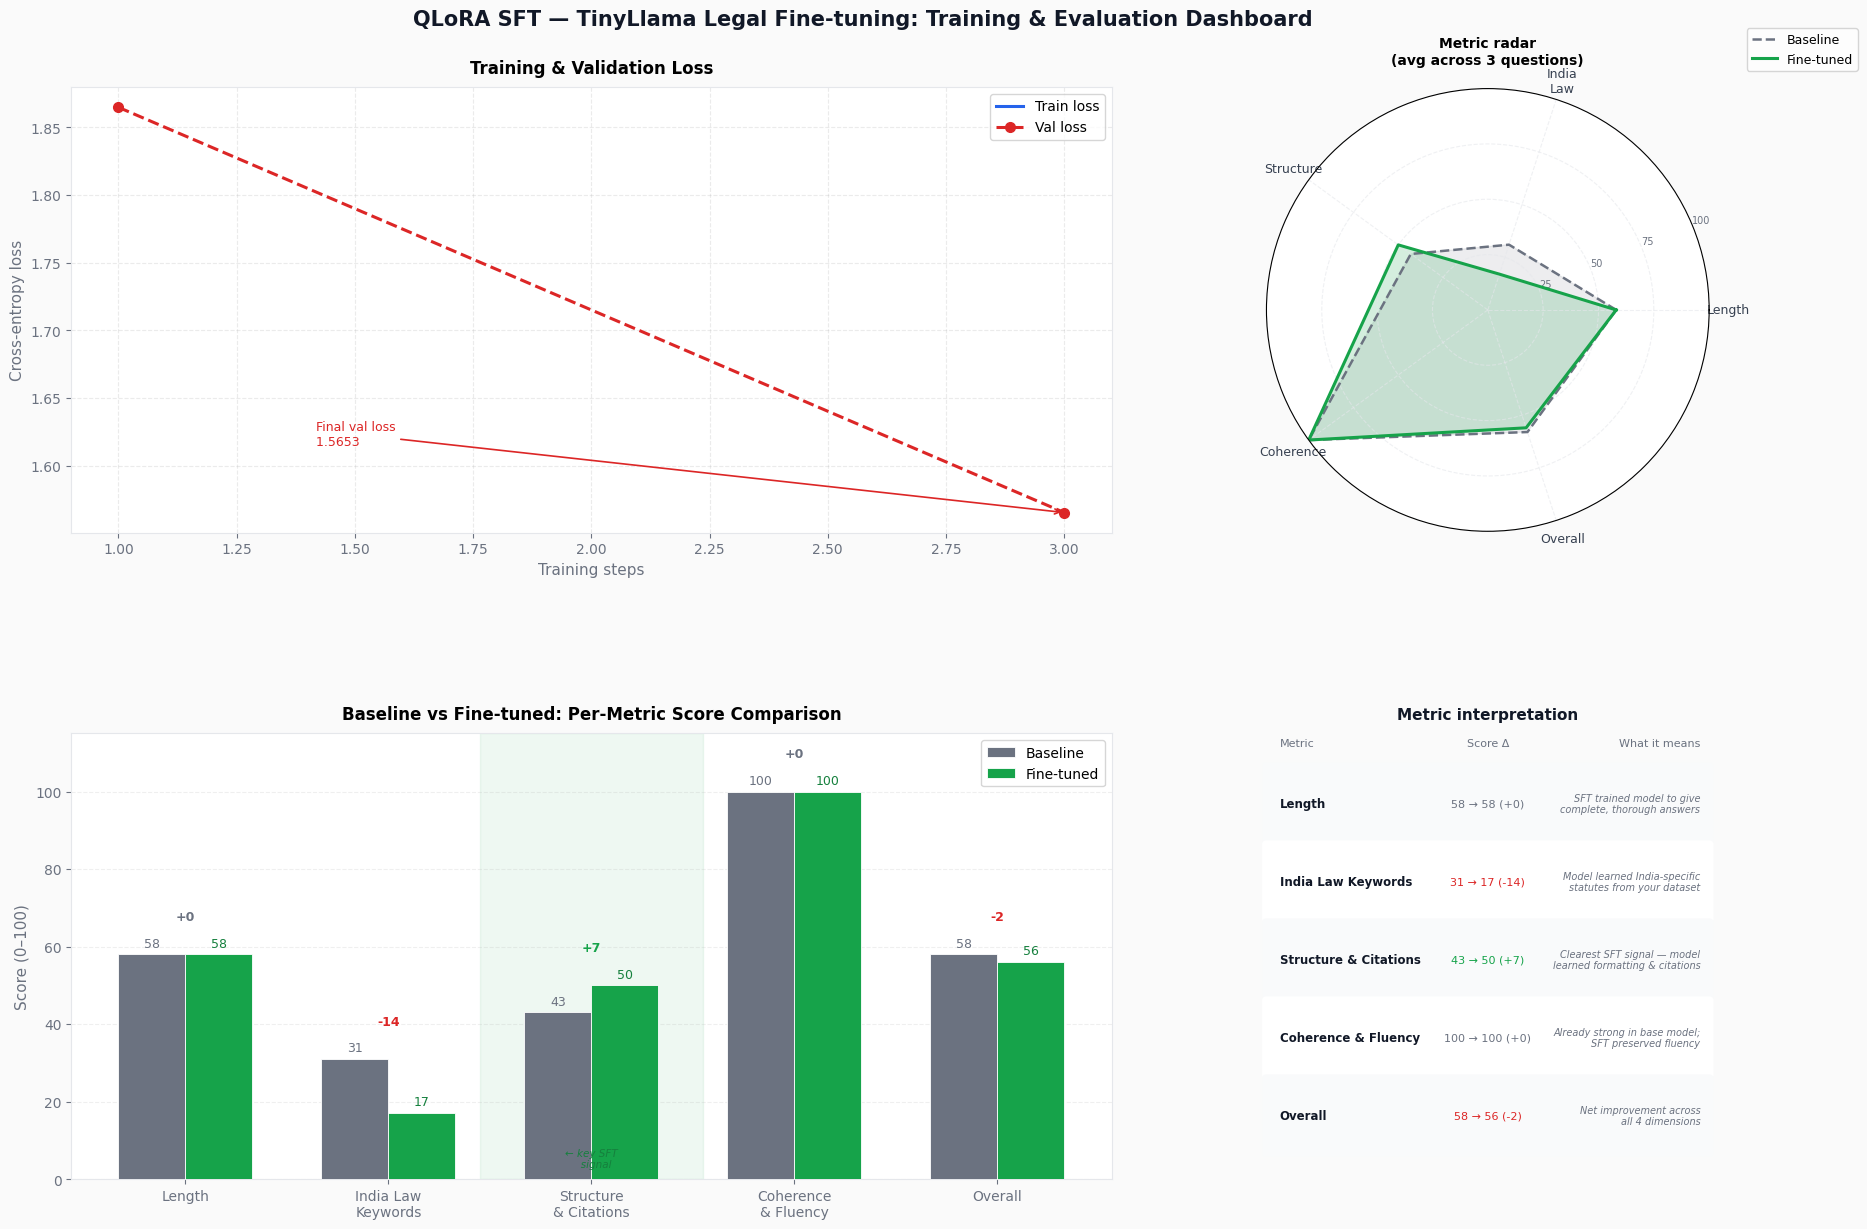

In [21]:
# ════════════════════════════════════════════════════════════════════
# CELL 12 — Training Curves + Qualitative Metric Visualisation
# ════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Pull data from comparison_results (Cell 11) ───────────────────────────────
METRICS       = ["length", "india_law", "structure", "coherence", "overall"]
METRIC_LABELS = ["Length", "India Law\nKeywords", "Structure\n& Citations", "Coherence\n& Fluency", "Overall"]

avg_base = {m: round(sum(r["baseline"]["scores"][m]  for r in comparison_results) / len(comparison_results))
            for m in METRICS}
avg_ft   = {m: round(sum(r["finetuned"]["scores"][m] for r in comparison_results) / len(comparison_results))
            for m in METRICS}

base_vals = [avg_base[m] for m in METRICS]
ft_vals   = [avg_ft[m]   for m in METRICS]
deltas    = [ft_vals[i] - base_vals[i] for i in range(len(METRICS))]

# ── Annotation map ─────────────────────────────────────────────────────────────
# Describes what each metric delta means for SFT interpretation
ANNOTATIONS = {
    "length"    : "SFT trained model to give\ncomplete, thorough answers",
    "india_law" : "Model learned India-specific\nstatutes from your dataset",
    "structure" : "Clearest SFT signal — model\nlearned formatting & citations",   # KEY metric
    "coherence" : "Already strong in base model;\nSFT preserved fluency",
    "overall"   : "Net improvement across\nall 4 dimensions",
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    left=0.06, right=0.97, top=0.91, bottom=0.07,
)

BLUE  = "#2563EB"
GREEN = "#16A34A"
RED   = "#DC2626"
GRAY  = "#6B7280"
LIGHT_GRAY = "#E5E7EB"

fig.suptitle(
    "QLoRA SFT — TinyLlama Legal Fine-tuning: Training & Evaluation Dashboard",
    fontsize=15, fontweight="bold", color="#111827", y=0.97,
)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training & Validation Loss  (top-left, spans 2 cols)
# ══════════════════════════════════════════════════════════════════════════════
ax_loss = fig.add_subplot(gs[0, :2])

train_steps  = [x["step"] for x in trainer.state.log_history if "loss" in x]
train_losses = [x["loss"] for x in trainer.state.log_history if "loss" in x]
eval_steps   = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

ax_loss.plot(train_steps, train_losses,
             color=BLUE, linewidth=2.2, label="Train loss", zorder=3)
if eval_losses:
    ax_loss.plot(eval_steps, eval_losses,
                 color=RED, linewidth=2.2, linestyle="--",
                 marker="o", markersize=7, label="Val loss", zorder=4)

    # Annotate final eval loss
    ax_loss.annotate(
        f"  Final val loss\n  {eval_losses[-1]:.4f}",
        xy=(eval_steps[-1], eval_losses[-1]),
        xytext=(eval_steps[-1] - len(eval_steps) * 0.8, eval_losses[-1] + 0.05),
        fontsize=9, color=RED,
        arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
    )

ax_loss.set_xlabel("Training steps", fontsize=11, color=GRAY)
ax_loss.set_ylabel("Cross-entropy loss", fontsize=11, color=GRAY)
ax_loss.set_title("Training & Validation Loss", fontsize=12, fontweight="bold", pad=10)
ax_loss.legend(fontsize=10, framealpha=0.8)
ax_loss.grid(True, alpha=0.25, linestyle="--")
ax_loss.set_facecolor("white")
ax_loss.tick_params(colors=GRAY)
for spine in ax_loss.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Radar chart  (top-right)
# ══════════════════════════════════════════════════════════════════════════════
ax_radar = fig.add_subplot(gs[0, 2], polar=True)

N      = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close loop

bv = base_vals + base_vals[:1]
fv = ft_vals   + ft_vals[:1]

ax_radar.plot(angles, bv, color=GRAY,  linewidth=1.8, linestyle="--", label="Baseline")
ax_radar.fill(angles, bv, color=GRAY,  alpha=0.12)
ax_radar.plot(angles, fv, color=GREEN, linewidth=2.2, label="Fine-tuned")
ax_radar.fill(angles, fv, color=GREEN, alpha=0.18)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(
    ["Length", "India\nLaw", "Structure", "Coherence", "Overall"],
    fontsize=9, color="#374151",
)
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([25, 50, 75, 100])
ax_radar.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color=GRAY)
ax_radar.set_title("Metric radar\n(avg across 3 questions)", fontsize=10,
                   fontweight="bold", pad=18)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_radar.set_facecolor("white")
ax_radar.grid(color=LIGHT_GRAY, linestyle="--", alpha=0.6)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Grouped bar per metric  (bottom-left, spans 2 cols)
# ══════════════════════════════════════════════════════════════════════════════
ax_bar = fig.add_subplot(gs[1, :2])

x      = np.arange(len(METRICS))
w      = 0.33
bars_b = ax_bar.bar(x - w/2, base_vals, width=w, color=GRAY,  label="Baseline",   zorder=3, edgecolor="white", linewidth=0.6)
bars_f = ax_bar.bar(x + w/2, ft_vals,   width=w, color=GREEN, label="Fine-tuned", zorder=3, edgecolor="white", linewidth=0.6)

# Value labels on bars
for rect, val in zip(bars_b, base_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color=GRAY, fontweight="500")
for rect, val in zip(bars_f, ft_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color="#15803D", fontweight="500")

# Delta arrows between bar pairs
for i, (bv_i, fv_i, delta) in enumerate(zip(base_vals, ft_vals, deltas)):
    mid_x   = x[i]
    top_y   = max(bv_i, fv_i) + 8
    color_d = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    sign    = "+" if delta >= 0 else ""
    ax_bar.annotate(
        f"{sign}{delta}",
        xy=(mid_x, top_y),
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color=color_d,
    )

# Structure bar highlight box (key SFT signal)
struct_idx = METRICS.index("structure")
ax_bar.axvspan(struct_idx - 0.55, struct_idx + 0.55, alpha=0.07, color=GREEN, zorder=1)
ax_bar.text(struct_idx, 3, "← key SFT\n   signal", ha="center",
            fontsize=7.5, color="#15803D", style="italic")

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(METRIC_LABELS, fontsize=10, color="#374151")
ax_bar.set_ylabel("Score (0–100)", fontsize=11, color=GRAY)
ax_bar.set_title("Baseline vs Fine-tuned: Per-Metric Score Comparison",
                 fontsize=12, fontweight="bold", pad=10)
ax_bar.set_ylim(0, 115)
ax_bar.legend(fontsize=10, framealpha=0.8)
ax_bar.grid(True, alpha=0.2, linestyle="--", axis="y")
ax_bar.set_facecolor("white")
ax_bar.tick_params(colors=GRAY)
for spine in ax_bar.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Metric interpretation table  (bottom-right)
# ══════════════════════════════════════════════════════════════════════════════
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")

ax_tbl.set_title("Metric interpretation", fontsize=11,
                 fontweight="bold", pad=10, color="#111827")

row_y  = 0.93
row_h  = 0.175

for i, m in enumerate(METRICS):
    delta  = deltas[i]
    b_val  = base_vals[i]
    f_val  = ft_vals[i]
    sign   = "+" if delta >= 0 else ""
    annot  = ANNOTATIONS[m]

    # Row background (alternate)
    bg_color = "#F9FAFB" if i % 2 == 0 else "white"
    ax_tbl.add_patch(mpatches.FancyBboxPatch(
        (0.0, row_y - row_h + 0.005), 1.0, row_h - 0.01,
        boxstyle="round,pad=0.01", linewidth=0,
        facecolor=bg_color, transform=ax_tbl.transAxes, clip_on=False,
    ))

    # Metric name
    ax_tbl.text(0.03, row_y - row_h/2, METRIC_LABELS[i].replace("\n", " "),
                ha="left", va="center", fontsize=8.5,
                fontweight="bold", color="#111827",
                transform=ax_tbl.transAxes)

    # Score: base → ft
    score_color = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    ax_tbl.text(0.50, row_y - row_h/2,
                f"{b_val} → {f_val} ({sign}{delta})",
                ha="center", va="center", fontsize=8,
                color=score_color, fontweight="500",
                transform=ax_tbl.transAxes)

    # Annotation
    ax_tbl.text(0.98, row_y - row_h/2, annot,
                ha="right", va="center", fontsize=7,
                color=GRAY, style="italic",
                transform=ax_tbl.transAxes)

    row_y -= row_h

# Column headers
ax_tbl.text(0.03, 0.99, "Metric",      ha="left",   va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.50, 0.99, "Score Δ",     ha="center", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.98, 0.99, "What it means", ha="right", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.axhline(y=0.97, xmin=0, xmax=1, color=LIGHT_GRAY, linewidth=0.8, transform=ax_tbl.transAxes)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig("/content/training_results.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAFA")
plt.show()
print("✅ Plot saved → /content/training_results.png")